In [ ]:
!pip install transformers datasets torch accelerate scikit-learn

In [ ]:
import torch
import numpy as np
import pandas as pd
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    EarlyStoppingCallback
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
def load_and_prepare_data(file_path):

    df = pd.read_csv("/content/15k_English.csv")

    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}")

    # Check sample reviews
    print("\nSample reviews:")
    for i in range(3):
        print(f"{i+1}. {df['review'].iloc[i][:100]}... -> {df['sentiment'].iloc[i]}")

    return df

In [ ]:
df = load_and_prepare_data('/content/15k_English.csv')

Dataset shape: (15034, 2)
Columns: ['review', 'sentiment']
Sentiment distribution:
sentiment
Positive    5147
Negative    5066
Neutral     4821
Name: count, dtype: int64

Sample reviews:
1. Two companies have given shoes... -> Negative
2. Keeps warm and uncomfortable at times... -> Neutral
3. I ordered 2 ton size, got that size,, my AC size is 1.5 ton. I ordered a size up based on someone's ... -> Positive


In [ ]:
# Convert sentiment to numerical labels
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['sentiment'].map(label_map)

# Check for missing values
print(f"\nMissing values: {df.isnull().sum()}")
df = df.dropna()  # Remove any missing values


Missing values: review       0
sentiment    0
label        0
dtype: int64


In [ ]:
def create_stratified_splits(df, test_size=0.2, val_size=0.1):

    # First split: 80% train+val, 20% test
    train_val_df, test_df = train_test_split(
        df, test_size=test_size, random_state=SEED, stratify=df['label']
    )

    # Second split: 87.5% of remaining -> 70% train, 10% val
    train_df, val_df = train_test_split(
        train_val_df, test_size=val_size/(1-test_size),
        random_state=SEED, stratify=train_val_df['label']
    )

    return train_df, val_df, test_df

# Create splits
train_df, val_df, test_df = create_stratified_splits(df)

print(f"\n📊 Dataset Split:")
print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} samples")


📊 Dataset Split:
Train: 10523 samples
Validation: 1504 samples
Test: 3007 samples
Total: 15034 samples


# **Model Implementation**

In [ ]:
def initialize_roberta_sentiment():
    """Initialize the pre-trained RoBERTa sentiment model"""
    model_name = "cardiffnlp/twitter-roberta-base-sentiment"

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        use_fast=True,
        truncation=True,
        padding=True
    )

    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    # Check the model's label mapping
    print("Model label mapping:", model.config.id2label)

    # Move to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"✅ Device: {device}")
    print(f"✅ Model: {model_name}")
    print(f"✅ Tokenizer max length: {tokenizer.model_max_length}")

    return tokenizer, model, device

tokenizer, model, device = initialize_roberta_sentiment()

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Model label mapping: {0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2'}
✅ Device: cuda
✅ Model: cardiffnlp/twitter-roberta-base-sentiment
✅ Tokenizer max length: 1000000000000000019884624838656


# **Tokenization**

In [ ]:
def tokenize_function(examples, max_length=128):
    """Tokenization function for RoBERTa"""
    return tokenizer(
        examples["review"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors=None
    )

# Create Hugging Face datasets
train_dataset = Dataset.from_dict({
    "review": train_df['review'].tolist(),
    "labels": train_df['label'].tolist()
})

val_dataset = Dataset.from_dict({
    "review": val_df['review'].tolist(),
    "labels": val_df['label'].tolist()
})

test_dataset = Dataset.from_dict({
    "review": test_df['review'].tolist(),
    "labels": test_df['label'].tolist()
})

# Tokenize datasets
max_seq_length = min(128, tokenizer.model_max_length)
tokenized_train = train_dataset.map(
    lambda x: tokenize_function(x, max_seq_length), batched=True
)
tokenized_val = val_dataset.map(
    lambda x: tokenize_function(x, max_seq_length), batched=True
)
tokenized_test = test_dataset.map(
    lambda x: tokenize_function(x, max_seq_length), batched=True
)

# Remove text columns to avoid conflicts
tokenized_train = tokenized_train.remove_columns(["review"])
tokenized_val = tokenized_val.remove_columns(["review"])
tokenized_test = tokenized_test.remove_columns(["review"])

# Set format for PyTorch
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

Map:   0%|          | 0/10523 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Map:   0%|          | 0/1504 [00:00<?, ? examples/s]

Map:   0%|          | 0/3007 [00:00<?, ? examples/s]

In [ ]:
def compute_metrics(p):
    """Comprehensive metrics for sentiment analysis"""
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')

    # Per-class metrics
    f1_per_class = f1_score(labels, predictions, average=None)
    precision_per_class = precision_score(labels, predictions, average=None)
    recall_per_class = recall_score(labels, predictions, average=None)

    return {
        'accuracy': accuracy,
        'f1_weighted': f1,
        'precision_weighted': precision,
        'recall_weighted': recall,
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
        'precision_negative': precision_per_class[0],
        'precision_neutral': precision_per_class[1],
        'precision_positive': precision_per_class[2],
        'recall_negative': recall_per_class[0],
        'recall_neutral': recall_per_class[1],
        'recall_positive': recall_per_class[2],
    }

# **Model Tuning**

In [ ]:
def get_training_args():
    """Optimized training arguments for RoBERTa sentiment"""
    return TrainingArguments(
        output_dir='./roberta-sentiment-models',
        num_train_epochs=4,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_dir='./logs',
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1_weighted",
        greater_is_better=True,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        dataloader_pin_memory=False,
        lr_scheduler_type="linear",
        report_to="none",
        seed=SEED,
    )

training_args = get_training_args()

In [ ]:
# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
print("🚀 Starting RoBERTa Sentiment Training...")
print(f"💻 Using device: {device}")
print(f"📊 Training samples: {len(tokenized_train)}")
print(f"📊 Validation samples: {len(tokenized_val)}")

# Train the model
train_results = trainer.train()

🚀 Starting RoBERTa Sentiment Training...
💻 Using device: cuda
📊 Training samples: 10523
📊 Validation samples: 1504


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted,F1 Negative,F1 Neutral,F1 Positive,Precision Negative,Precision Neutral,Precision Positive,Recall Negative,Recall Neutral,Recall Positive
1,0.327300,0.308560,0.878989,0.877791,0.880052,0.878989,0.898000,0.828790,0.903758,0.910751,0.873563,0.855903,0.885602,0.788382,0.957282
2,0.257700,0.282831,0.894947,0.895060,0.895218,0.894947,0.900688,0.857438,0.924731,0.898039,0.853909,0.931102,0.903353,0.860996,0.918447
3,0.158700,0.338138,0.894947,0.895250,0.895980,0.894947,0.904523,0.856562,0.922330,0.922131,0.840319,0.922330,0.887574,0.873444,0.922330
4,0.096800,0.369152,0.896941,0.896713,0.896642,0.896941,0.902270,0.862539,0.923225,0.903162,0.872611,0.912713,0.901381,0.852697,0.933981


# **Model Saving**

In [ ]:
# Save the best model
trainer.save_model("./models/roberta-sentiment-final")
tokenizer.save_pretrained("./models/roberta-sentiment-final")
print("✅ Training completed and model saved!")

✅ Training completed and model saved!


# **Confusion Matrix & Classification Report**


📊 Comprehensive Evaluation on Test Set:


✅ Accuracy: 0.8896
✅ F1-Score (Weighted): 0.8890
✅ Precision (Weighted): 0.8891
✅ Recall (Weighted): 0.8896

📊 Per-Class Metrics:
✅ F1-Negative: 0.9066
✅ F1-Neutral: 0.8427
✅ F1-Positive: 0.9151

📈 Confusion Matrix:
[[917  78  18]
 [ 75 793  96]
 [ 18  47 965]]


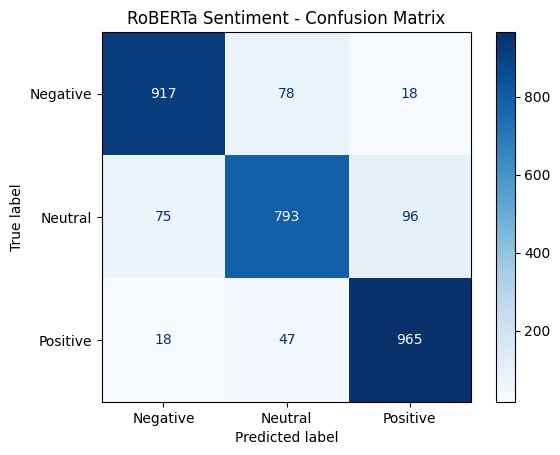

In [ ]:
def comprehensive_evaluation(trainer, test_dataset):
    """Complete evaluation on test set"""
    print("\n📊 Comprehensive Evaluation on Test Set:")

    # Get predictions
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=1)
    labels = predictions.label_ids

    # Calculate metrics
    metrics = compute_metrics((predictions.predictions, labels))

    # Print results
    print(f"✅ Accuracy: {metrics['accuracy']:.4f}")
    print(f"✅ F1-Score (Weighted): {metrics['f1_weighted']:.4f}")
    print(f"✅ Precision (Weighted): {metrics['precision_weighted']:.4f}")
    print(f"✅ Recall (Weighted): {metrics['recall_weighted']:.4f}")

    print(f"\n📊 Per-Class Metrics:")
    print(f"✅ F1-Negative: {metrics['f1_negative']:.4f}")
    print(f"✅ F1-Neutral: {metrics['f1_neutral']:.4f}")
    print(f"✅ F1-Positive: {metrics['f1_positive']:.4f}")

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    print(f"\n📈 Confusion Matrix:\n{cm}")

    # Plot confusion matrix
    from sklearn.metrics import ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Negative', 'Neutral', 'Positive'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title('RoBERTa Sentiment - Confusion Matrix')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    return metrics, cm

# Evaluate
test_metrics, confusion_matrix = comprehensive_evaluation(trainer, tokenized_test)

In [ ]:
class SentimentAnalyzer:
    def __init__(self, model_path):
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()

        # Map model outputs to your labels
        self.id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}
        self.label_emojis = {"Negative": "😠", "Neutral": "😐", "Positive": "😊"}
        self.label_colors = {"Negative": "#ff4d4d", "Neutral": "#ffcc00", "Positive": "#4CAF50"}

    def predict(self, text):
        """Predict sentiment for a given text"""
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )

        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs)

        probs = torch.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][predicted_class].item()

        return {
            'sentiment': self.id2label[predicted_class],
            'confidence': confidence,
            'emoji': self.label_emojis[self.id2label[predicted_class]],
            'color': self.label_colors[self.id2label[predicted_class]],
            'probabilities': {
                'Negative': probs[0][0].item(),
                'Neutral': probs[0][1].item(),
                'Positive': probs[0][2].item()
            }
        }

    def predict_batch(self, texts):
        """Predict sentiment for multiple texts"""
        results = []
        for text in texts:
            results.append(self.predict(text))
        return results

# Initialize predictor
analyzer = SentimentAnalyzer("./models/roberta-sentiment-final")

# **Output Analysing**

In [ ]:
def test_sample_predictions(analyzer, sample_texts):
    """Test the model on sample texts"""
    print("\n🧪 Sample Predictions:")
    print("=" * 70)

    for i, text in enumerate(sample_texts, 1):
        result = analyzer.predict(text)
        print(f"\n{i}. {text}")
        print(f"   🎯 {result['emoji']} {result['sentiment'].upper()} "
              f"(confidence: {result['confidence']:.3f})")
        print(f"   📊 NEG: {result['probabilities']['Negative']:.3f} | "
              f"NEU: {result['probabilities']['Neutral']:.3f} | "
              f"POS: {result['probabilities']['Positive']:.3f}")

# Test samples
sample_texts = [
    "This product is absolutely amazing! Best purchase ever!",
    "The quality is okay, but the price is too high for what you get.",
    "Terrible product. Broke after one week of use.",
    "It's decent, nothing special but gets the job done.",
    "I'm extremely disappointed with this purchase."
]

test_sample_predictions(analyzer, sample_texts)


🧪 Sample Predictions:

1. This product is absolutely amazing! Best purchase ever!
   🎯 😊 POSITIVE (confidence: 0.997)
   📊 NEG: 0.002 | NEU: 0.001 | POS: 0.997

2. The quality is okay, but the price is too high for what you get.
   🎯 😐 NEUTRAL (confidence: 0.628)
   📊 NEG: 0.366 | NEU: 0.628 | POS: 0.006

3. Terrible product. Broke after one week of use.
   🎯 😠 NEGATIVE (confidence: 0.999)
   📊 NEG: 0.999 | NEU: 0.000 | POS: 0.001

4. It's decent, nothing special but gets the job done.
   🎯 😐 NEUTRAL (confidence: 0.998)
   📊 NEG: 0.001 | NEU: 0.998 | POS: 0.002

5. I'm extremely disappointed with this purchase.
   🎯 😠 NEGATIVE (confidence: 0.999)
   📊 NEG: 0.999 | NEU: 0.000 | POS: 0.001


In [ ]:
def save_final_results(metrics, file_path="final_results.json"):
    """Save final results for analysis"""
    import json

    results = {
        'model': 'twitter-roberta-base-sentiment',
        'dataset_size': len(df),
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df),
        'test_metrics': metrics,
        'hyperparameters': {
            'learning_rate': 2e-5,
            'batch_size': 32,
            'epochs': 3,
            'max_length': max_seq_length,
            'weight_decay': 0.01
        }
    }

    with open(file_path, 'w') as f:
        json.dump(results, f, indent=4)

    print(f"✅ Results saved to {file_path}")

save_final_results(test_metrics)

✅ Results saved to final_results.json


In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def compute_metrics_with_probs(p):
    """Compute metrics including probabilities for AUC calculation"""
    predictions, labels = p
    predictions_probs = torch.softmax(torch.tensor(predictions), dim=-1).numpy()
    predictions_class = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions_class)
    f1 = f1_score(labels, predictions_class, average='weighted')

    return {
        'accuracy': accuracy,
        'f1_weighted': f1,
        'predictions_probs': predictions_probs,
        'labels': labels
    }

# **Visualization**

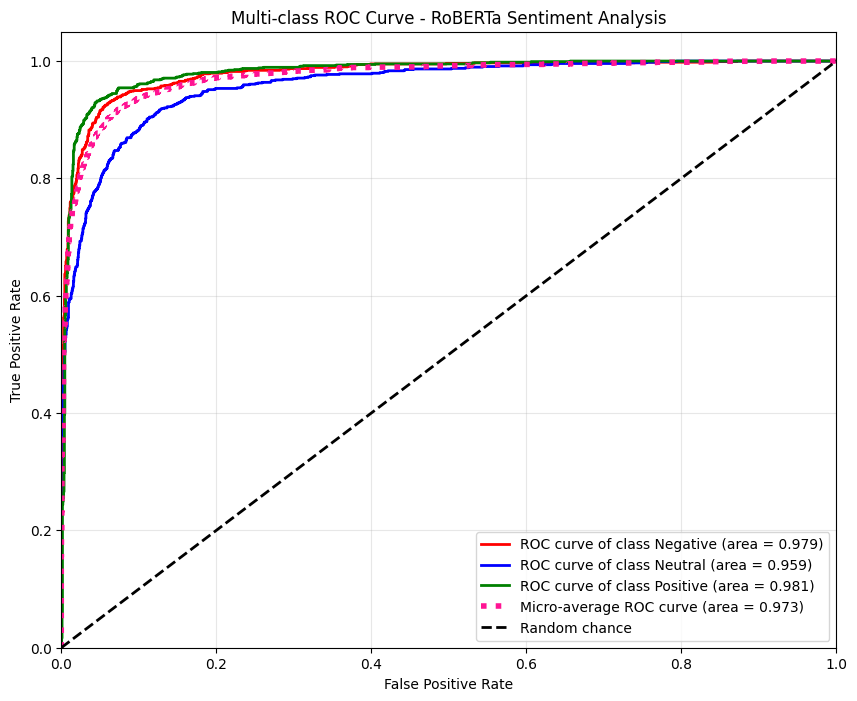

In [ ]:
def plot_auc_curves(trainer, test_dataset, class_names=None):
    """Generate AUC curves for multi-class classification"""
    if class_names is None:
        class_names = ['Negative', 'Neutral', 'Positive']

    # Get predictions with probabilities
    predictions = trainer.predict(test_dataset)
    y_probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
    y_true = predictions.label_ids

    # Binarize the labels for multi-class ROC
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = y_true_bin.shape[1]

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))

    # Plot each class
    colors = ['red', 'blue', 'green', 'orange']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.3f})'
                 ''.format(class_names[i], roc_auc[i]))

    # Plot micro-average
    plt.plot(fpr["micro"], tpr["micro"],
             label='Micro-average ROC curve (area = {0:0.3f})'
             ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)

    # Plot random chance line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random chance')

    # Customize the plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve - RoBERTa Sentiment Analysis')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # Save the plot
    plt.savefig('auc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    return roc_auc, fpr, tpr

# Generate AUC curves
roc_auc, fpr, tpr = plot_auc_curves(trainer, tokenized_test)

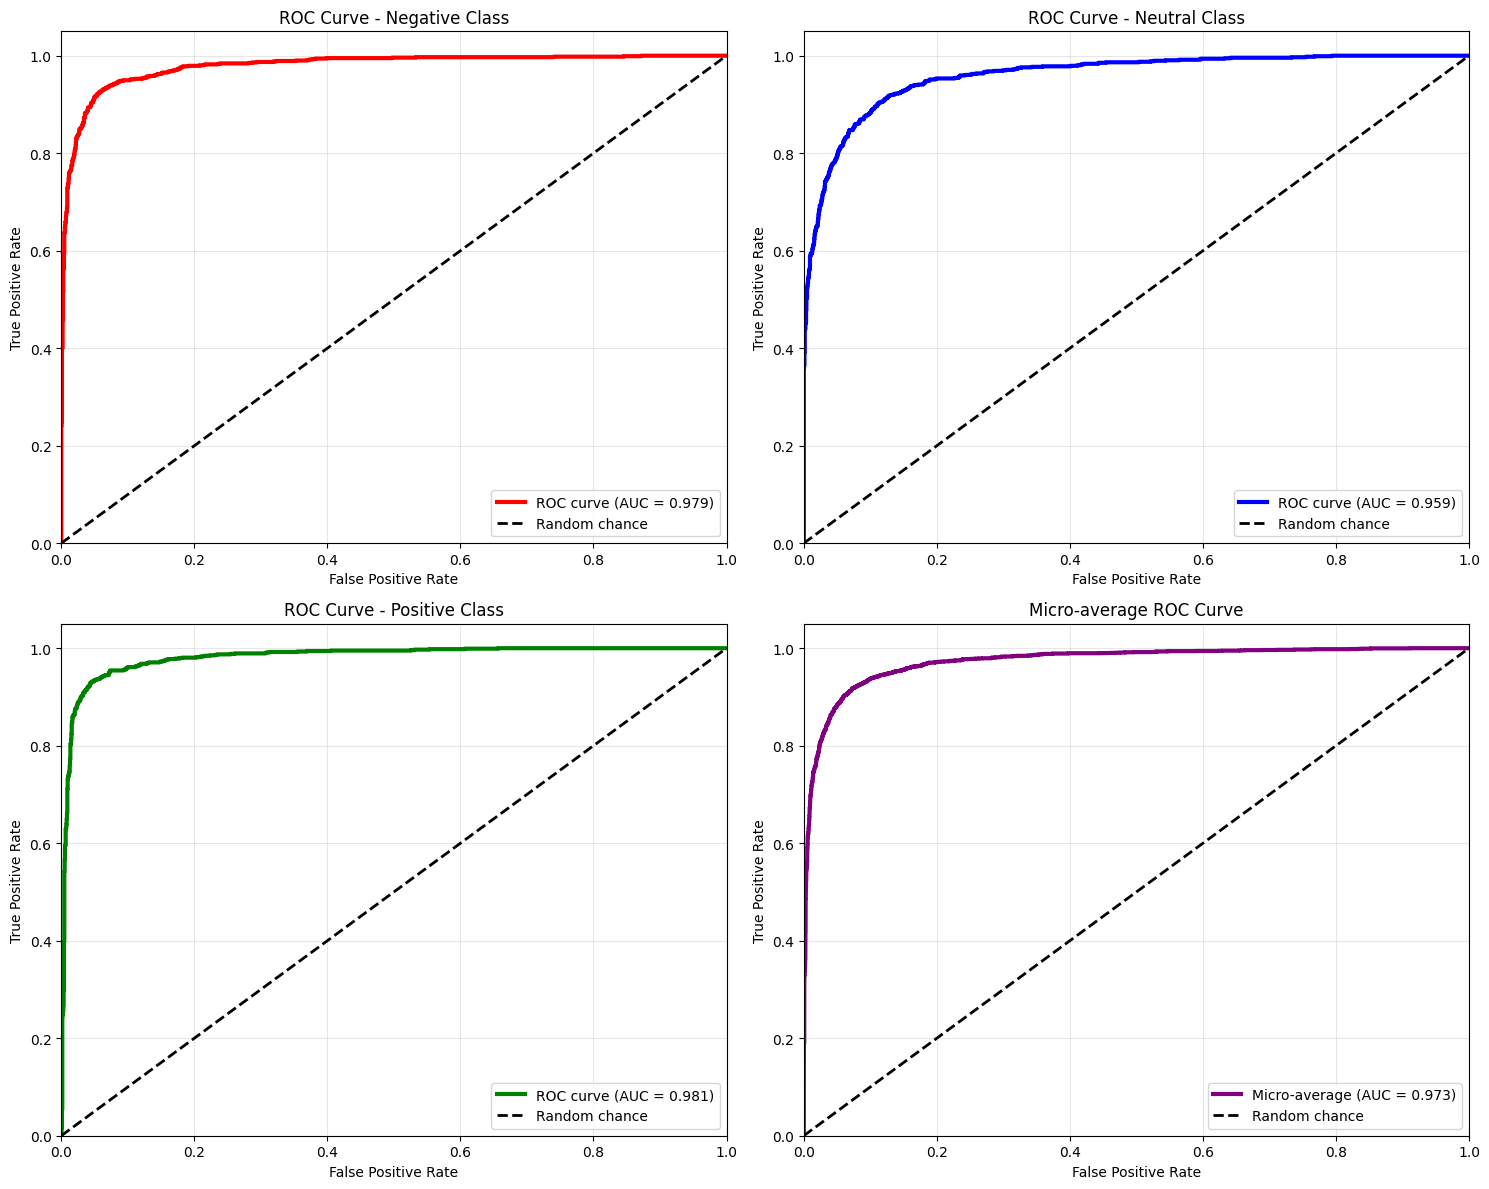

In [ ]:
def plot_individual_roc_curves(fpr, tpr, roc_auc, class_names):
    """Plot individual ROC curves for each class"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()

    colors = ['red', 'blue', 'green']

    # Plot each class separately
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        axes[i].plot(fpr[i], tpr[i], color=color, lw=3,
                    label='ROC curve (AUC = {0:0.3f})'.format(roc_auc[i]))
        axes[i].plot([0, 1], [0, 1], 'k--', lw=2, label='Random chance')
        axes[i].set_xlim([0.0, 1.0])
        axes[i].set_ylim([0.0, 1.05])
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].set_title(f'ROC Curve - {class_name} Class')
        axes[i].legend(loc="lower right")
        axes[i].grid(True, alpha=0.3)

    # Plot micro-average in the last subplot
    axes[3].plot(fpr["micro"], tpr["micro"], color='purple', lw=3,
                label='Micro-average (AUC = {0:0.3f})'.format(roc_auc["micro"]))
    axes[3].plot([0, 1], [0, 1], 'k--', lw=2, label='Random chance')
    axes[3].set_xlim([0.0, 1.0])
    axes[3].set_ylim([0.0, 1.05])
    axes[3].set_xlabel('False Positive Rate')
    axes[3].set_ylabel('True Positive Rate')
    axes[3].set_title('Micro-average ROC Curve')
    axes[3].legend(loc="lower right")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('individual_roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot individual curves
plot_individual_roc_curves(fpr, tpr, roc_auc, ['Negative', 'Neutral', 'Positive'])

In [ ]:
def comprehensive_evaluation_with_auc(trainer, test_dataset, class_names=None):
    """Complete evaluation including AUC metrics"""
    if class_names is None:
        class_names = ['Negative', 'Neutral', 'Positive']

    print("\n📊 Comprehensive Evaluation with AUC:")
    print("=" * 60)

    # Get predictions
    predictions = trainer.predict(test_dataset)
    y_probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids

    # Calculate basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    # Calculate AUC scores
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    auc_scores = {}

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        auc_scores[class_name] = auc(fpr, tpr)

    # Micro-average AUC
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
    auc_scores['Micro-average'] = auc(fpr_micro, tpr_micro)

    # Print results
    print(f"✅ Accuracy: {accuracy:.4f}")
    print(f"✅ F1-Score (Weighted): {f1:.4f}")
    print(f"✅ Precision (Weighted): {precision:.4f}")
    print(f"✅ Recall (Weighted): {recall:.4f}")

    print(f"\n📊 AUC Scores:")
    for class_name, score in auc_scores.items():
        print(f"✅ {class_name}: {score:.4f}")

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'auc_scores': auc_scores,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_probs': y_probs
    }

# Run enhanced evaluation
eval_results = comprehensive_evaluation_with_auc(trainer, tokenized_test)


📊 Comprehensive Evaluation with AUC:


✅ Accuracy: 0.8896
✅ F1-Score (Weighted): 0.8890
✅ Precision (Weighted): 0.8891
✅ Recall (Weighted): 0.8896

📊 AUC Scores:
✅ Negative: 0.9786
✅ Neutral: 0.9588
✅ Positive: 0.9815
✅ Micro-average: 0.9730


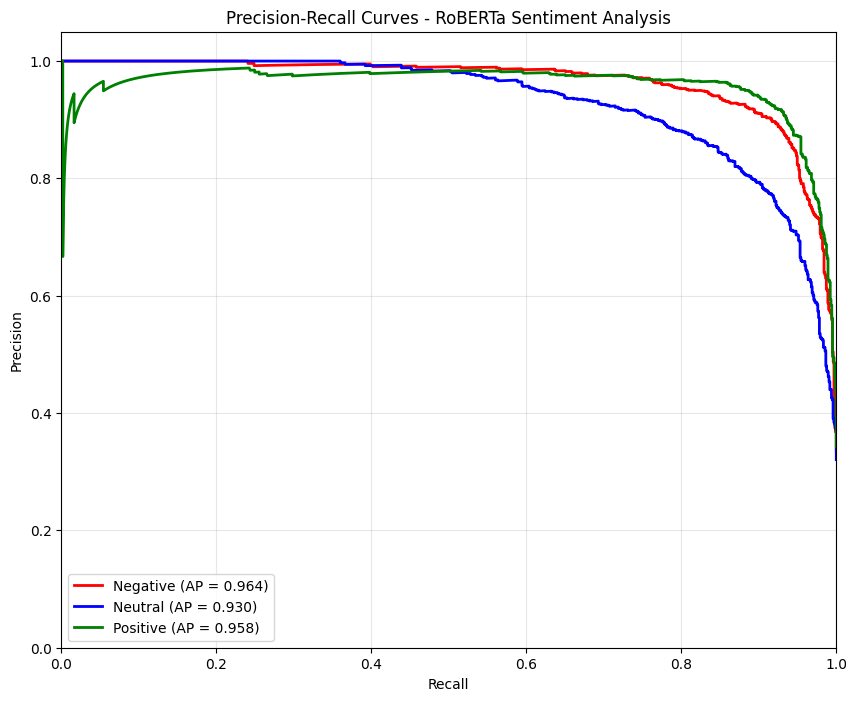

In [ ]:
def plot_precision_recall_curves(y_true, y_probs, class_names):
    """Plot Precision-Recall curves for each class"""
    from sklearn.metrics import precision_recall_curve, average_precision_score

    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = len(class_names)

    plt.figure(figsize=(10, 8))

    colors = ['red', 'blue', 'green', 'orange']

    # Plot each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        avg_precision = average_precision_score(y_true_bin[:, i], y_probs[:, i])

        plt.plot(recall, precision, color=color, lw=2,
                label='{0} (AP = {1:0.3f})'.format(class_name, avg_precision))

    # Customize the plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves - RoBERTa Sentiment Analysis')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)

    # Save the plot
    plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot Precision-Recall curves
plot_precision_recall_curves(eval_results['y_true'], eval_results['y_probs'],
                           ['Negative', 'Neutral', 'Positive'])